<a href="https://colab.research.google.com/github/Dina-Shanjida/next_word_prediction_using_LSTM/blob/main/Next_word_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install kagglehub

In [3]:
import os, re, random, math, time
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
import kagglehub

path = kagglehub.dataset_download("ronikdedhia/next-word-prediction")
print(path)

Using Colab cache for faster access to the 'next-word-prediction' dataset.
/kaggle/input/next-word-prediction


In [5]:
files = os.listdir(path)
print(files)

['1661-0.txt', '.nfs00000000ad8ac69900000011']


In [6]:
file_path = path + "/" + files[0]

if file_path.endswith(".txt"):
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        raw_text = f.read()

elif file_path.endswith(".csv"):
    df = pd.read_csv(file_path)
    text_col = df.select_dtypes(include="object").columns[0]
    raw_text = " ".join(df[text_col].astype(str))

print(raw_text[:500])

﻿
Project Gutenberg's The Adventures of Sherlock Holmes, by Arthur Conan Doyle

This eBook is for the use of anyone anywhere at no cost and with
almost no restrictions whatsoever.  You may copy it, give it away or
re-use it under the terms of the Project Gutenberg License included
with this eBook or online at www.gutenberg.net


Title: The Adventures of Sherlock Holmes

Author: Arthur Conan Doyle

Release Date: November 29, 2002 [EBook #1661]
Last Updated: May 20, 2019

Language: English

Charac


## preprocessing

In [28]:
def preprocess_pipeline(text):
    start = re.search(r"\*\*\* START OF (THIS|THE) PROJECT GUTENBERG EBOOK \*\*\*", text)
    if start:
        text = text[start.end():]

    end = re.search(r"\*\*\* END OF (THIS|THE) PROJECT GUTENBERG EBOOK \*\*\*", text)
    if end:
        text = text[:end.start()]

    text = re.sub(r"Title:.*", "", text)
    text = re.sub(r"Author:.*", "", text)
    text = re.sub(r"Release Date:.*", "", text)
    text = re.sub(r"Language:.*", "", text)
    text = re.sub(r"Chapter\s+\d+.*", "", text)

    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s\.!\?]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

clean_text = preprocess_pipeline(raw_text)

print(clean_text[:500])

project gutenberg s the adventures of sherlock holmes by arthur conan doyle this ebook is for the use of anyone anywhere at no cost and with almost no restrictions whatsoever. you may copy it give it away or re use it under the terms of the project gutenberg license included with this ebook or online at last updated may character set encoding utf start of this project gutenberg ebook the adventures of sherlock holmes produced by an anonymous project gutenberg volunteer and jose menendez cover th


## tokenization

In [26]:
tokens = clean_text.split()
print(len(tokens))
print(len(set(tokens)))

107584
15212


## vocabulary

In [9]:
MIN_FREQ = 5

freq = Counter(tokens)
vocab_words = [w for w, c in freq.most_common() if c >= MIN_FREQ]

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for w in vocab_words:
    word2idx[w] = len(word2idx)

idx2word = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = len(word2idx)

print(VOCAB_SIZE)

2198


## text to index

In [10]:
UNK_IDX = word2idx[UNK_TOKEN]
token_ids = [word2idx.get(t, UNK_IDX) for t in tokens]

print(token_ids[:10])

[138, 139, 45, 2, 1129, 6, 118, 46, 44, 538]


## create sequences

In [11]:
SEQ_LEN = 10

sequences, targets = [], []
for i in range(len(token_ids) - SEQ_LEN):
    sequences.append(token_ids[i:i+SEQ_LEN])
    targets.append(token_ids[i+SEQ_LEN])

split = int(0.9 * len(sequences))

train_seqs = sequences[:split]
val_seqs = sequences[split:]

train_tgts = targets[:split]
val_tgts = targets[split:]

## dataset and dataloader

In [12]:
class NextWordDataset(Dataset):
    def __init__(self, seqs, tgts):
        self.X = torch.tensor(seqs, dtype=torch.long)
        self.y = torch.tensor(tgts, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 128

train_ds = NextWordDataset(train_seqs, train_tgts)
val_ds = NextWordDataset(val_seqs, val_tgts)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## lstm model

In [14]:
class LSTMNextWord(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout, pad_idx):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.emb_drop = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
        embed_dim,
        hidden_dim,
        num_layers=num_layers,
        batch_first=True,
        dropout=dropout,
        bidirectional=True
        )

        self.fc_drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim*2, vocab_size)

    def forward(self, x):
        emb = self.emb_drop(self.embedding(x))
        out, _ = self.lstm(emb)
        out = self.fc_drop(out[:, -1, :])
        logits = self.fc(out)
        return logits

EMBED_DIM = 256
HIDDEN_DIM = 512
NUM_LAYERS = 2
DROPOUT = 0.3

model = LSTMNextWord(
    VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM,
    NUM_LAYERS, DROPOUT, pad_idx=0
).to(device)

print(model)

LSTMNextWord(
  (embedding): Embedding(2198, 256, padding_idx=0)
  (emb_drop): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(256, 512, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc_drop): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=1024, out_features=2198, bias=True)
)


In [15]:
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

## training

In [16]:
EPOCHS = 10
CLIP_NORM = 5.0

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss = 0
    total = 0

    with torch.enable_grad() if training else torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)

            logits = model(X)
            loss = criterion(logits, y)

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
                optimizer.step()

            total_loss += loss.item() * y.size(0)
            total += y.size(0)

    return total_loss / total

history = {"train_loss": [], "val_loss": []}

for epoch in range(EPOCHS):
    tr_loss = run_epoch(train_loader, True)
    val_loss = run_epoch(val_loader, False)

    scheduler.step(val_loss)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)

    print(epoch+1, tr_loss, val_loss)

1 5.015237528859167 5.178323134963085
2 4.4943901206099 5.046275348449886
3 4.216592003797716 5.017605206831248
4 3.97364454886815 5.049292679599306
5 3.745840987329492 5.0990184869837964
6 3.5181253577198186 5.207691363119637
7 3.1265699685657498 5.3356478717694085
8 2.9394176000096426 5.410496147941656
9 2.7831765283572696 5.500426649850479
10 2.5474534825148463 5.600292751929493


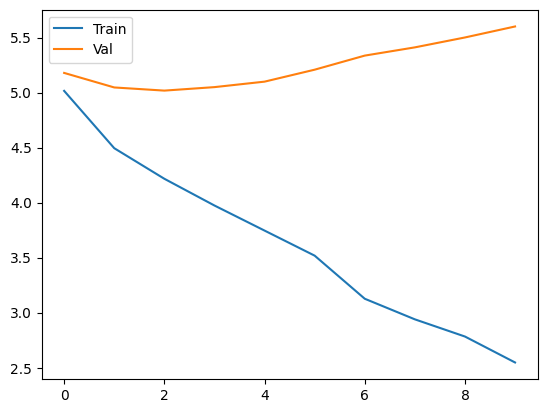

In [17]:
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.legend()
plt.show()

## prediction function

In [29]:
def predict_next_word(seed_text, top_k=5):
    model.eval()

    words = preprocess_pipeline(seed_text).split()
    ids = [word2idx.get(w, UNK_IDX) for w in words]

    if len(ids) < SEQ_LEN:
        ids = [0]*(SEQ_LEN-len(ids)) + ids
    else:
        ids = ids[-SEQ_LEN:]

    x = torch.tensor([ids]).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=-1).squeeze()

    top_probs, top_ids = torch.topk(probs, top_k)

    for p, i in zip(top_probs, top_ids):
        print(idx2word[i.item()], round(p.item()*100, 2), "%")

In [30]:
predict_next_word("once upon a time")

which 21.81 %
of 20.37 %
and 20.19 %
in 17.03 %
that 5.63 %


## generate text

In [32]:
def generate_text(seed_text, num_words=30):
    model.eval()

    words = preprocess_pipeline(seed_text).split()
    ids = [word2idx.get(w, UNK_IDX) for w in words]
    generated = list(words)

    with torch.no_grad():
        for _ in range(num_words):
            ctx = ids[-SEQ_LEN:] if len(ids) >= SEQ_LEN else [0]*(SEQ_LEN-len(ids))+ids
            x = torch.tensor([ctx]).to(device)

            logits = model(x)
            probs = torch.softmax(logits, dim=-1).squeeze()
            next_id = torch.multinomial(probs, 1).item()

            next_word = idx2word[next_id]
            generated.append(next_word)
            ids.append(next_id)

    return " ".join(generated)

In [33]:
print(generate_text("once upon a time"))

once upon a time and a pair of <UNK> paper who was in front of him in every <UNK> perhaps he was very willing to put me until he had only picked up the
